# EV Ecosystem Stock Network Analysis

This project studies the electric vehicle (EV) ecosystem as a financial network. The objective is not to forecast stock prices, but to understand how companies in the sector move together after removing broad market exposure.

Each company is represented as a node. Edges are created when two companies have a strong correlation in their market-neutral returns. The network is then used to identify central firms, hubs, communities, and possible channels of sector risk transmission.

The analysis is useful for portfolio and risk analysis because highly connected stocks may offer less diversification, while central or bridge firms can indicate areas where shocks may spread through the sector.


In [1]:
# If running this notebook in a new environment, install the required packages first.
# !pip install yfinance networkx numpy pandas matplotlib scikit-learn node2vec python-louvain


In [2]:
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import yfinance as yf
from node2vec import Node2Vec
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    normalized_mutual_info_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import community as community_louvain

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)


## 1. Data and Market Universe

The sample is restricted to companies that belong to the EV ecosystem rather than the entire stock market. This gives the network an economic interpretation: firms are linked through manufacturing, suppliers, semiconductors, batteries, materials, software, and mobility platforms.

The market benchmark is `SPY`. It is included so that broad market movement can be removed before the network is constructed.


In [3]:
start_date = "2022-01-01"
end_date = "2026-07-11"  # yfinance treats this as an exclusive end date.
market = "SPY"

tickers = [
    # Automakers
    "TSLA", "TM", "VOW.DE", "BMW.DE", "MBGYY", "F", "GM", "STLA", "HMC",
    "005380.KS", "BYDDY", "0175.HK", "NIO", "LI", "XPEV", "RIVN", "LCID",

    # Tier-1 suppliers
    "MGA", "APTV", "BWA", "LEA", "DNZOY", "VLEEY",

    # Semiconductors
    "NVDA", "QCOM", "AMD", "INTC", "TXN", "NXPI", "STM", "IFNNY", "TSM",

    # Batteries and materials
    "ALB", "SQM", "373220.KS", "006400.KS", "6752.T",

    # Mobility and autonomy
    "UBER", "DIDIY", "MBLY", "BIDU", "GOOGL",
]

data = yf.download(
    tickers + [market],
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
)["Close"].sort_index()

print("Download shape:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())
data.head()


Download shape: (1177, 43)
Date range: 2022-01-03 00:00:00 to 2026-07-10 00:00:00


Ticker,005380.KS,006400.KS,0175.HK,373220.KS,6752.T,ALB,AMD,APTV,BIDU,BMW.DE,BWA,BYDDY,DIDIY,DNZOY,F,GM,GOOGL,HMC,IFNNY,INTC,LCID,LEA,LI,MBGYY,MBLY,MGA,NIO,NVDA,NXPI,QCOM,RIVN,SPY,SQM,STLA,STM,TM,TSLA,TSM,TXN,UBER,VLEEY,VOW.DE,XPEV
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,19.192429,NaN,NaN,223.750687,150.240005,166.029999,149.100006,66.016037,37.334232,11.212281,5.25,20.187765,16.218876,58.752007,143.717148,25.138689,44.225536,49.350483,409.299988,165.443665,32.340000,13.336450,NaN,69.789627,33.470001,30.026142,212.404175,168.570129,102.720001,449.486450,42.504280,14.260361,48.266266,168.699463,399.926666,119.708557,167.298294,43.950001,13.040355,176.602020,50.270000
2022-01-04,173604.546875,643979.1875,19.147375,NaN,1179.547729,229.338074,144.419998,172.210007,146.529999,68.083328,39.606670,11.131861,5.00,20.701300,18.111202,63.141350,143.130356,25.723106,43.556171,49.285564,394.100006,172.213974,30.330000,13.994364,NaN,73.373604,31.580000,29.197762,213.919952,169.493500,101.389999,449.335907,41.138573,14.807714,47.727829,180.381409,383.196655,123.983833,167.473831,44.419998,13.382174,181.788391,47.599998
2022-01-05,176497.937500,642986.8750,17.912933,NaN,1195.185669,222.776901,136.149994,168.279999,143.880005,69.565132,39.639732,10.293875,5.02,20.851488,17.626945,60.259949,136.564041,25.531206,43.030251,49.962605,366.799988,168.337585,29.170000,14.268495,NaN,72.791969,29.879999,27.517063,206.295364,168.832642,90.010002,440.707672,39.932064,14.858800,46.497147,178.352905,362.706665,118.091362,163.980392,43.240002,13.501809,185.777863,46.110001
2022-01-06,176911.296875,637033.3125,17.930952,NaN,1170.611694,220.640289,136.229996,174.119995,150.750000,69.550674,40.242966,10.255273,4.70,21.001671,18.222958,60.384808,136.536804,25.932449,42.915501,50.092457,382.200012,170.320435,28.379999,14.563184,NaN,73.091354,29.309999,28.089260,208.490875,168.334747,87.330002,440.293671,41.105064,15.231000,47.227859,180.888504,354.899994,119.401840,163.927734,42.029999,13.459083,181.921356,46.660000
2022-01-07,177737.968750,631079.7500,17.516470,NaN,1175.526367,223.136154,132.000000,169.470001,153.330002,69.102509,40.176853,10.147510,4.50,21.035583,18.208057,59.808533,135.812729,25.949896,43.450989,49.563797,419.799988,167.203247,29.180000,14.302761,NaN,73.185432,29.299999,27.161192,203.319016,163.319550,86.279999,438.552979,41.859131,14.917184,47.977821,181.513351,342.320007,114.782639,157.502655,41.509998,13.373627,180.325562,45.049999


In [4]:
print("Number of columns:", data.shape[1])
print(data.columns.tolist())

data.head()


Number of columns: 43
['005380.KS', '006400.KS', '0175.HK', '373220.KS', '6752.T', 'ALB', 'AMD', 'APTV', 'BIDU', 'BMW.DE', 'BWA', 'BYDDY', 'DIDIY', 'DNZOY', 'F', 'GM', 'GOOGL', 'HMC', 'IFNNY', 'INTC', 'LCID', 'LEA', 'LI', 'MBGYY', 'MBLY', 'MGA', 'NIO', 'NVDA', 'NXPI', 'QCOM', 'RIVN', 'SPY', 'SQM', 'STLA', 'STM', 'TM', 'TSLA', 'TSM', 'TXN', 'UBER', 'VLEEY', 'VOW.DE', 'XPEV']


Ticker,005380.KS,006400.KS,0175.HK,373220.KS,6752.T,ALB,AMD,APTV,BIDU,BMW.DE,BWA,BYDDY,DIDIY,DNZOY,F,GM,GOOGL,HMC,IFNNY,INTC,LCID,LEA,LI,MBGYY,MBLY,MGA,NIO,NVDA,NXPI,QCOM,RIVN,SPY,SQM,STLA,STM,TM,TSLA,TSM,TXN,UBER,VLEEY,VOW.DE,XPEV
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,19.192429,NaN,NaN,223.750687,150.240005,166.029999,149.100006,66.016037,37.334232,11.212281,5.25,20.187765,16.218876,58.752007,143.717148,25.138689,44.225536,49.350483,409.299988,165.443665,32.340000,13.336450,NaN,69.789627,33.470001,30.026142,212.404175,168.570129,102.720001,449.486450,42.504280,14.260361,48.266266,168.699463,399.926666,119.708557,167.298294,43.950001,13.040355,176.602020,50.270000
2022-01-04,173604.546875,643979.1875,19.147375,NaN,1179.547729,229.338074,144.419998,172.210007,146.529999,68.083328,39.606670,11.131861,5.00,20.701300,18.111202,63.141350,143.130356,25.723106,43.556171,49.285564,394.100006,172.213974,30.330000,13.994364,NaN,73.373604,31.580000,29.197762,213.919952,169.493500,101.389999,449.335907,41.138573,14.807714,47.727829,180.381409,383.196655,123.983833,167.473831,44.419998,13.382174,181.788391,47.599998
2022-01-05,176497.937500,642986.8750,17.912933,NaN,1195.185669,222.776901,136.149994,168.279999,143.880005,69.565132,39.639732,10.293875,5.02,20.851488,17.626945,60.259949,136.564041,25.531206,43.030251,49.962605,366.799988,168.337585,29.170000,14.268495,NaN,72.791969,29.879999,27.517063,206.295364,168.832642,90.010002,440.707672,39.932064,14.858800,46.497147,178.352905,362.706665,118.091362,163.980392,43.240002,13.501809,185.777863,46.110001
2022-01-06,176911.296875,637033.3125,17.930952,NaN,1170.611694,220.640289,136.229996,174.119995,150.750000,69.550674,40.242966,10.255273,4.70,21.001671,18.222958,60.384808,136.536804,25.932449,42.915501,50.092457,382.200012,170.320435,28.379999,14.563184,NaN,73.091354,29.309999,28.089260,208.490875,168.334747,87.330002,440.293671,41.105064,15.231000,47.227859,180.888504,354.899994,119.401840,163.927734,42.029999,13.459083,181.921356,46.660000
2022-01-07,177737.968750,631079.7500,17.516470,NaN,1175.526367,223.136154,132.000000,169.470001,153.330002,69.102509,40.176853,10.147510,4.50,21.035583,18.208057,59.808533,135.812729,25.949896,43.450989,49.563797,419.799988,167.203247,29.180000,14.302761,NaN,73.185432,29.299999,27.161192,203.319016,163.319550,86.279999,438.552979,41.859131,14.917184,47.977821,181.513351,342.320007,114.782639,157.502655,41.509998,13.373627,180.325562,45.049999


## 2. Data Coverage and Cleaning

Before building the network, I check whether each ticker has enough price history. Different listing dates and exchange calendars can create missing values, and sparse data would make correlation estimates unreliable.

Tickers with more than 10 percent missing prices are removed. After that, remaining rows with missing values are dropped so every stock is measured over the same trading dates.


In [5]:
coverage = pd.DataFrame({
    "nan_share": data.isna().mean(),
    "first_valid": data.apply(lambda s: s.first_valid_index()),
    "last_valid": data.apply(lambda s: s.last_valid_index()),
    "non_null": data.notna().sum(),
}).sort_values("nan_share", ascending=False)

coverage.head(15)


,nan_share,first_valid,last_valid,non_null
Ticker,,,,
MBLY,0.211555,2022-10-26,2026-07-10,928
373220.KS,0.078165,2022-01-27,2026-07-10,1085
006400.KS,0.063721,2022-01-04,2026-07-10,1102
005380.KS,0.063721,2022-01-04,2026-07-10,1102
6752.T,0.061172,2022-01-04,2026-07-10,1105
0175.HK,0.059473,2022-01-03,2026-07-10,1107
SPY,0.037383,2022-01-03,2026-07-10,1133
MGA,0.037383,2022-01-03,2026-07-10,1133
NIO,0.037383,2022-01-03,2026-07-10,1133


In [6]:
max_nan_share = 0.10

nan_share = data.isna().mean().sort_values(ascending=False)
keep_cols = nan_share[nan_share <= max_nan_share].index.tolist()
removed_cols = nan_share[nan_share > max_nan_share].index.tolist()

data_filt = data[keep_cols]
data_clean = data_filt.dropna()

print("Tickers kept:", len(keep_cols))
print("Tickers removed:", removed_cols)
print("Original shape:", data.shape)
print("After ticker filtering:", data_filt.shape)
print("After dropping remaining NaNs:", data_clean.shape)
print("Any NaNs left?", data_clean.isna().any().any())
print("Original date range:", data.index.min(), "to", data.index.max())
print("Cleaned date range:", data_clean.index.min(), "to", data_clean.index.max())

nan_share[nan_share > max_nan_share].to_frame("nan_share")


Tickers kept: 42
Tickers removed: ['MBLY']
Original shape: (1177, 43)
After ticker filtering: (1177, 42)
After dropping remaining NaNs: (954, 42)
Any NaNs left? False
Original date range: 2022-01-03 00:00:00 to 2026-07-10 00:00:00
Cleaned date range: 2022-01-27 00:00:00 to 2026-07-10 00:00:00


,nan_share
Ticker,
MBLY,0.211555


## 3. Log Returns

The network is based on returns, not price levels. I use log returns because they are standard in financial analysis and behave well when returns are aggregated over time.


In [7]:
returns = np.log(data_clean / data_clean.shift(1)).iloc[1:]

print("Returns shape:", returns.shape)
returns.head()


Returns shape: (953, 42)


Ticker,373220.KS,006400.KS,005380.KS,6752.T,0175.HK,SPY,MGA,NIO,NVDA,NXPI,QCOM,RIVN,SQM,VLEEY,STLA,MBGYY,TM,TSLA,TSM,TXN,UBER,STM,LEA,LI,LCID,ALB,AMD,APTV,BIDU,BWA,BYDDY,DIDIY,DNZOY,F,GM,GOOGL,HMC,IFNNY,INTC,XPEV,BMW.DE,VOW.DE
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-28,-0.115311,0.000000,0.000000,0.028068,-0.038943,0.024532,-0.013934,-0.009998,0.040019,0.007896,0.034209,0.057282,-0.007590,-0.027158,-0.007782,-0.007635,0.016550,0.020592,0.010513,0.020688,0.032326,0.036058,-0.021448,0.021932,-0.055520,0.003887,0.025406,-0.007833,0.019294,-0.019269,-0.076467,-0.047253,0.011375,0.004617,-0.023799,0.033134,0.000345,-0.022920,-0.006682,-0.014207,-0.017168,-0.023568
2022-02-04,0.113329,-0.011854,0.018593,-0.028893,0.036625,0.015158,0.024165,0.136637,0.062745,0.044748,0.073153,0.063586,0.039829,0.050772,-0.010471,-0.004610,0.019231,0.087043,0.028582,-0.033670,0.050938,-0.017755,0.023418,0.180094,0.014625,0.046379,0.160807,0.009271,0.077767,0.015122,0.089231,-0.084083,0.031231,-0.084317,0.020684,0.071907,0.020816,-0.011016,0.013438,0.147239,-0.030102,-0.021696
2022-02-07,0.083699,-0.032903,-0.018593,-0.007876,0.000000,-0.003215,0.006887,0.001251,0.016678,-0.006075,-0.024708,-0.042110,0.042810,-0.002833,-0.016986,-0.013957,0.001827,-0.017459,0.010603,-0.008612,0.013139,-0.007416,0.017035,-0.002442,-0.021277,0.017256,0.000566,-0.010341,-0.017709,0.001615,0.007613,0.037307,-0.018349,-0.003905,-0.011373,-0.028973,-0.002028,-0.021613,0.003535,-0.010525,0.002228,-0.007338
2022-02-08,0.000000,0.000000,0.000000,0.004567,-0.022288,0.008194,0.007584,0.028761,0.015250,0.028090,0.019793,0.043423,0.018356,0.045068,0.009590,0.004674,0.015495,0.016028,0.011381,0.015646,0.021087,0.024511,0.006314,0.012841,0.016912,0.030956,0.036209,0.025654,0.046400,0.025491,-0.003394,0.091462,0.002720,-0.009548,-0.024959,0.001421,0.001691,-0.014316,0.012991,0.008375,0.000556,-0.001638
2022-02-09,-0.069906,0.000000,0.000000,0.014395,0.022288,0.014530,0.023986,0.055537,0.061665,0.035076,0.029571,0.057076,0.037943,0.030710,0.041034,0.044587,0.005228,0.010788,0.014525,0.023359,0.047124,0.040972,0.005753,0.038225,0.049779,0.042069,0.035395,0.036857,0.022507,0.004932,0.030615,0.017835,0.034698,0.034936,0.025156,0.015609,0.029952,0.052788,0.022286,0.091463,0.037333,0.049570


## 4. Market Neutralization

Raw stock returns often move together because the whole market moves. If the network were built from raw correlations, it would mostly capture market beta rather than EV-sector structure.

To reduce this effect, each stock return is regressed on `SPY`:

$$
r_i = \alpha_i + \beta_i r_{SPY} + \varepsilon_i
$$

The residual $\varepsilon_i$ is the part of the stock return not explained by the broad market benchmark. The network is built from correlations between these residuals.


In [8]:
market_ret = returns[market]
asset_rets = returns.drop(columns=[market])

X = np.column_stack([np.ones(len(market_ret)), market_ret.to_numpy()])

betas = {}
residuals = pd.DataFrame(index=asset_rets.index)

for col in asset_rets.columns:
    y = asset_rets[col].to_numpy()
    alpha, beta = np.linalg.lstsq(X, y, rcond=None)[0]
    betas[col] = {"alpha": alpha, "beta": beta}
    residuals[col] = y - X @ np.array([alpha, beta])

betas_df = pd.DataFrame(betas).T

print("Residuals shape:", residuals.shape)
betas_df.head()


Residuals shape: (953, 41)


,alpha,beta
373220.KS,-0.000624,0.252381
006400.KS,-0.000493,0.264268
005380.KS,0.000978,0.250926
6752.T,0.001386,0.159888
0175.HK,-0.000091,0.429656


## 5. Network Construction

The graph is constructed from correlations between market-neutral residual returns.

- Node: one company stock
- Edge: residual correlation with absolute value at least 0.20
- Weight: absolute residual correlation, so graph algorithms receive positive relationship strengths
- `corr` edge attribute: the signed correlation, kept for interpretation
- Direction: undirected, because correlation is symmetric

The analysis focuses on the largest connected component because path-based network measures are easier to interpret inside one connected graph.


In [9]:
corr = residuals.corr()
threshold = 0.20

corr_thresholded = corr.where(np.abs(corr) >= threshold, other=0.0).copy()
np.fill_diagonal(corr_thresholded.values, 0.0)

A = corr_thresholded.abs()
G = nx.from_pandas_adjacency(A)

for u, v, data_edge in G.edges(data=True):
    signed_corr = float(corr.loc[u, v])
    data_edge["corr"] = signed_corr
    data_edge["weight"] = abs(signed_corr)

largest_cc = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc).copy()

negative_edges = sum(1 for _, _, d in G.edges(data=True) if d["corr"] < 0)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Negative-correlation edges kept:", negative_edges)
print("Isolated nodes:", sum(1 for n in G.nodes if G.degree(n) == 0))
print("Connected components:", nx.number_connected_components(G))
print("Largest CC nodes:", G_cc.number_of_nodes())
print("Largest CC edges:", G_cc.number_of_edges())


Nodes: 41
Edges: 193
Negative-correlation edges kept: 0
Isolated nodes: 2
Connected components: 3
Largest CC nodes: 39
Largest CC edges: 193


In [10]:
threshold_grid = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

rows = []
for th in threshold_grid:
    A_tmp = corr.where(np.abs(corr) >= th, other=0.0).abs()
    np.fill_diagonal(A_tmp.values, 0.0)
    G_tmp = nx.from_pandas_adjacency(A_tmp)

    largest_component = max(nx.connected_components(G_tmp), key=len)
    rows.append({
        "threshold": th,
        "nodes": G_tmp.number_of_nodes(),
        "edges": G_tmp.number_of_edges(),
        "isolates": sum(1 for n in G_tmp.nodes if G_tmp.degree(n) == 0),
        "components": nx.number_connected_components(G_tmp),
        "largest_cc_nodes": len(largest_component),
        "largest_cc_share": len(largest_component) / G_tmp.number_of_nodes(),
        "density": nx.density(G_tmp),
    })

threshold_check = pd.DataFrame(rows)
threshold_check


,threshold,nodes,edges,isolates,components,largest_cc_nodes,largest_cc_share,density
0,0.15,41,259,2,3,39,0.951220,0.315854
1,0.20,41,193,2,3,39,0.951220,0.235366
2,0.25,41,133,2,6,23,0.560976,0.162195
3,0.30,41,90,5,9,22,0.536585,0.109756
4,0.35,41,62,6,14,11,0.268293,0.075610
5,0.40,41,44,8,17,6,0.146341,0.053659


The threshold check is used to choose a cutoff that removes weak correlations without breaking the graph into too many small pieces. A threshold of 0.20 keeps a large connected component while filtering out weaker relationships.


In [11]:
nx.write_gexf(G_cc, "G_cc.gexf")
nx.write_gexf(G, "G_full.gexf")

print("Saved: G_cc.gexf and G_full.gexf")


Saved: G_cc.gexf and G_full.gexf


## Gephi Visualization

The graph is also shown using the Gephi layout exported from the network. This visualization is useful for presentation because it makes the central core, bridge positions, and community-like structure easier to see than a basic notebook layout.


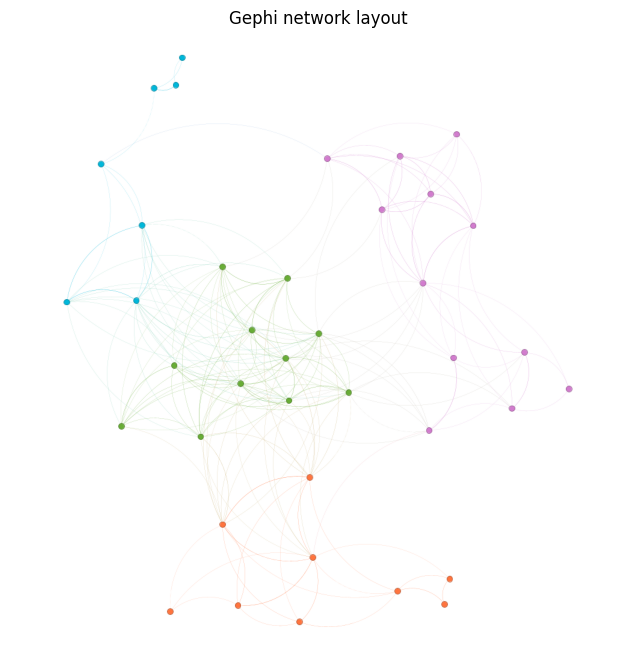

In [12]:
from pathlib import Path
import matplotlib.image as mpimg

gephi_image_path = Path("web .png")

if gephi_image_path.exists():
    img = mpimg.imread(gephi_image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Gephi network layout")
    plt.show()
else:
    print(f"Gephi image not found: {gephi_image_path}")


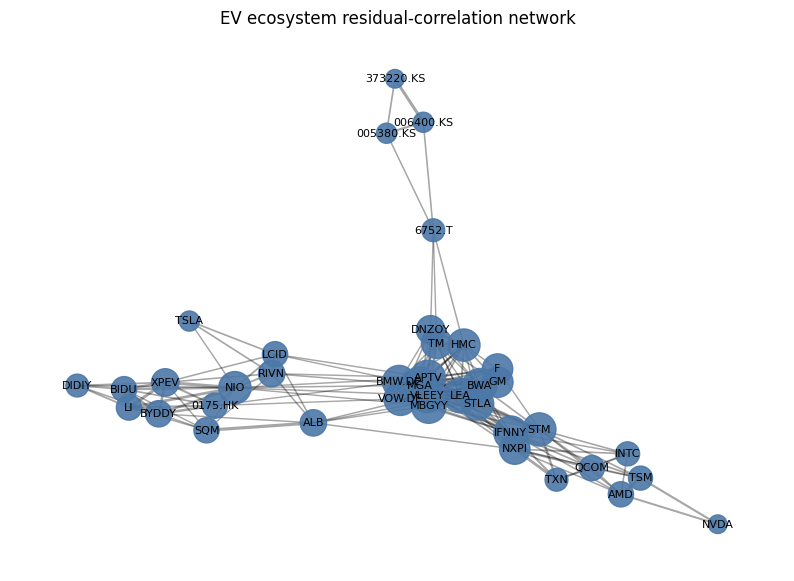

In [13]:
pos = nx.spring_layout(G_cc, seed=42, weight="weight")
node_sizes = [120 + 30 * G_cc.degree(n) for n in G_cc.nodes()]
edge_widths = [0.5 + 2.5 * G_cc[u][v]["weight"] for u, v in G_cc.edges()]

plt.figure(figsize=(10, 7))
nx.draw_networkx_edges(G_cc, pos, alpha=0.35, width=edge_widths)
nx.draw_networkx_nodes(G_cc, pos, node_size=node_sizes, node_color="#4C78A8", alpha=0.90)
nx.draw_networkx_labels(G_cc, pos, font_size=8)
plt.title("EV ecosystem residual-correlation network")
plt.axis("off")
plt.show()


## 6. Degree Distribution and Hubs

Degree counts how many strong relationships each stock has. A hub is a stock with unusually many connections compared with the rest of the network.


G_cc nodes: 39
G_cc edges: 193
Degree min/mean/max: 2 9.897435897435898 19


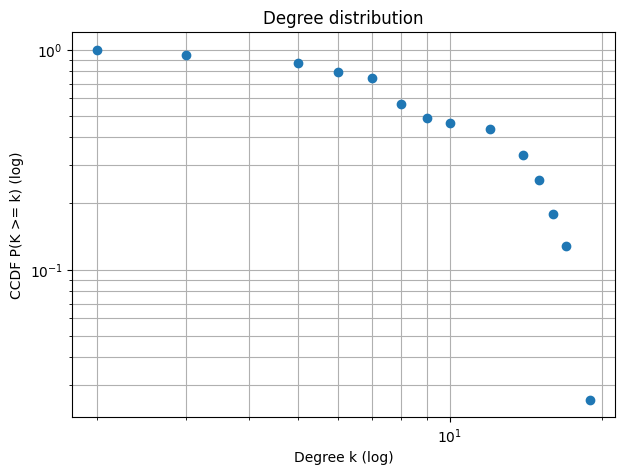

In [14]:
degree_sample = np.array([d for _, d in G_cc.degree()])

print("G_cc nodes:", G_cc.number_of_nodes())
print("G_cc edges:", G_cc.number_of_edges())
print("Degree min/mean/max:", degree_sample.min(), degree_sample.mean(), degree_sample.max())

x = np.sort(np.unique(degree_sample))
ccdf = np.array([(degree_sample >= k).mean() for k in x])

plt.figure(figsize=(7, 5))
plt.loglog(x, ccdf, marker="o", linestyle="none")
plt.xlabel("Degree k (log)")
plt.ylabel("CCDF P(K >= k) (log)")
plt.title("Degree distribution")
plt.grid(True, which="both")
plt.show()


The degree distribution is right-skewed: most firms have a moderate number of strong links, while a smaller group of firms is much more connected. In a financial-risk interpretation, these highly connected firms are important because their movements are shared with many other stocks in the sector.


In [15]:
hub_percentile = 85
hub_threshold = np.percentile(degree_sample, hub_percentile)
hubs = [n for n, d in G_cc.degree() if d >= hub_threshold]
hub_subgraph = G_cc.subgraph(hubs).copy()

print(f"Hub degree threshold ({hub_percentile}th percentile):", hub_threshold)
print("Hubs:", hubs)
print("Number of hubs:", len(hubs))
print("Hub subgraph nodes:", hub_subgraph.number_of_nodes())
print("Hub subgraph edges:", hub_subgraph.number_of_edges())
print("Hub subgraph connected components:", nx.number_connected_components(hub_subgraph))

if hub_subgraph.number_of_nodes() > 0:
    hub_comp_sizes = sorted([len(c) for c in nx.connected_components(hub_subgraph)], reverse=True)
    print("Hub component sizes:", hub_comp_sizes)


Hub degree threshold (85th percentile): 16.0
Hubs: ['MGA', 'VLEEY', 'MBGYY', 'LEA', 'APTV', 'BWA', 'IFNNY']
Number of hubs: 7
Hub subgraph nodes: 7
Hub subgraph edges: 21
Hub subgraph connected components: 1
Hub component sizes: [7]


Hubs are defined as the top 15 percent of stocks by degree. If these hubs are connected to each other, they form a dense core rather than acting as separate influential firms.


## 7. Centrality Analysis

Centrality measures describe different types of importance.

- Degree: many direct connections
- Strength: sum of weighted connections
- Eigenvector centrality: connections to other important nodes
- Betweenness: bridge position between parts of the graph
- PageRank: global importance based on connections to important nodes

Betweenness is calculated without weights because correlation strength is a similarity measure, not a distance.


In [16]:
metrics_df = pd.DataFrame(index=G_cc.nodes())
metrics_df["degree"] = pd.Series(dict(G_cc.degree()))
metrics_df["strength"] = pd.Series(dict(G_cc.degree(weight="weight")))
metrics_df["degree_centrality"] = pd.Series(nx.degree_centrality(G_cc))
metrics_df["betweenness"] = pd.Series(nx.betweenness_centrality(G_cc, weight=None))
metrics_df["eigenvector"] = pd.Series(nx.eigenvector_centrality(G_cc, max_iter=5000, weight="weight"))
metrics_df["pagerank"] = pd.Series(nx.pagerank(G_cc, weight="weight"))

metrics_df.sort_values("eigenvector", ascending=False).head(15)


,degree,strength,degree_centrality,betweenness,eigenvector,pagerank
LEA,17,6.226861,0.447368,0.033034,0.308656,0.038955
MGA,19,6.416978,0.500000,0.118807,0.299458,0.040869
MBGYY,17,5.893299,0.447368,0.060467,0.288733,0.037154
BWA,16,5.333993,0.421053,0.021259,0.272738,0.033686
VLEEY,17,5.486946,0.447368,0.060467,0.269562,0.034945
BMW.DE,15,5.143174,0.394737,0.034887,0.264973,0.032490
STLA,14,4.945988,0.368421,0.008238,0.262750,0.031134
VOW.DE,15,4.976646,0.394737,0.034887,0.255785,0.031603
APTV,17,5.293928,0.447368,0.079739,0.255180,0.034345
GM,12,4.312009,0.315789,0.000284,0.235982,0.027372


In [17]:
def top_n_ranks(centrality_dict, n=10):
    return sorted(centrality_dict, key=centrality_dict.get, reverse=True)[:n]

top_degree = top_n_ranks(nx.degree_centrality(G_cc), n=10)
top_eigenvector = top_n_ranks(nx.eigenvector_centrality(G_cc, max_iter=5000, weight="weight"), n=10)
top_betweenness = top_n_ranks(nx.betweenness_centrality(G_cc, weight=None), n=10)
top_pagerank = top_n_ranks(nx.pagerank(G_cc, weight="weight"), n=10)

rank_table = pd.DataFrame({
    "degree": top_degree,
    "eigenvector": top_eigenvector,
    "betweenness": top_betweenness,
    "pagerank": top_pagerank,
})

super_central = sorted(set(top_degree) & set(top_eigenvector) & set(top_betweenness) & set(top_pagerank))

print("Common to all four top-10 lists:", super_central)
rank_table


Common to all four top-10 lists: ['APTV', 'MBGYY', 'MGA', 'VLEEY']


,degree,eigenvector,betweenness,pagerank
0,MGA,LEA,NIO,MGA
1,VLEEY,MGA,6752.T,LEA
2,MBGYY,MBGYY,MGA,NIO
3,LEA,BWA,IFNNY,MBGYY
4,APTV,VLEEY,STM,IFNNY
5,BWA,BMW.DE,APTV,STM
6,IFNNY,STLA,HMC,VLEEY
7,STM,VOW.DE,NXPI,APTV
8,BMW.DE,APTV,VLEEY,BWA
9,VOW.DE,GM,MBGYY,BMW.DE


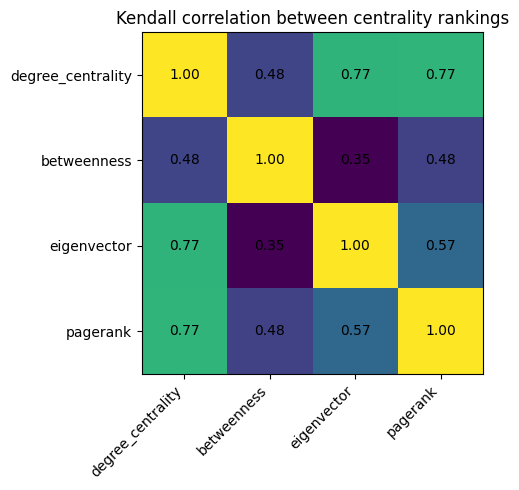

,degree_centrality,betweenness,eigenvector,pagerank
degree_centrality,1.000000,0.482875,0.771979,0.774776
betweenness,0.482875,1.000000,0.347427,0.475498
eigenvector,0.771979,0.347427,1.000000,0.568151
pagerank,0.774776,0.475498,0.568151,1.000000


In [18]:
centrality_cols = ["degree_centrality", "betweenness", "eigenvector", "pagerank"]
corr_c = metrics_df[centrality_cols].corr(method="kendall")

plt.figure(figsize=(6, 5))
plt.imshow(corr_c.values)
plt.xticks(range(len(centrality_cols)), centrality_cols, rotation=45, ha="right")
plt.yticks(range(len(centrality_cols)), centrality_cols)

for i in range(len(centrality_cols)):
    for j in range(len(centrality_cols)):
        plt.text(j, i, f"{corr_c.values[i, j]:.2f}", ha="center", va="center")

plt.title("Kendall correlation between centrality rankings")
plt.tight_layout()
plt.show()

corr_c


The centrality measures are positively related, but they do not measure exactly the same role. Degree and eigenvector centrality focus on connectedness and core position, while betweenness highlights firms that act as bridges between groups.


## 8. Clustering, Triangles, and Random Graph Comparison

A triangle means that three stocks are all mutually connected. A high triangle count and a high clustering coefficient indicate that firms form tight groups rather than isolated pairwise relationships.


In [19]:
triangles = nx.triangles(G_cc)
tri_sample = np.array(list(triangles.values()))

clustering = nx.clustering(G_cc)
clustering_values = np.array(list(clustering.values()))

structure_summary = pd.DataFrame({
    "metric": [
        "triangles_min",
        "triangles_mean",
        "triangles_max",
        "average_clustering",
        "density",
    ],
    "value": [
        tri_sample.min(),
        tri_sample.mean(),
        tri_sample.max(),
        clustering_values.mean(),
        nx.density(G_cc),
    ],
})

structure_summary


,metric,value
0,triangles_min,1.000000
1,triangles_mean,38.692308
2,triangles_max,101.000000
3,average_clustering,0.725043
4,density,0.260459


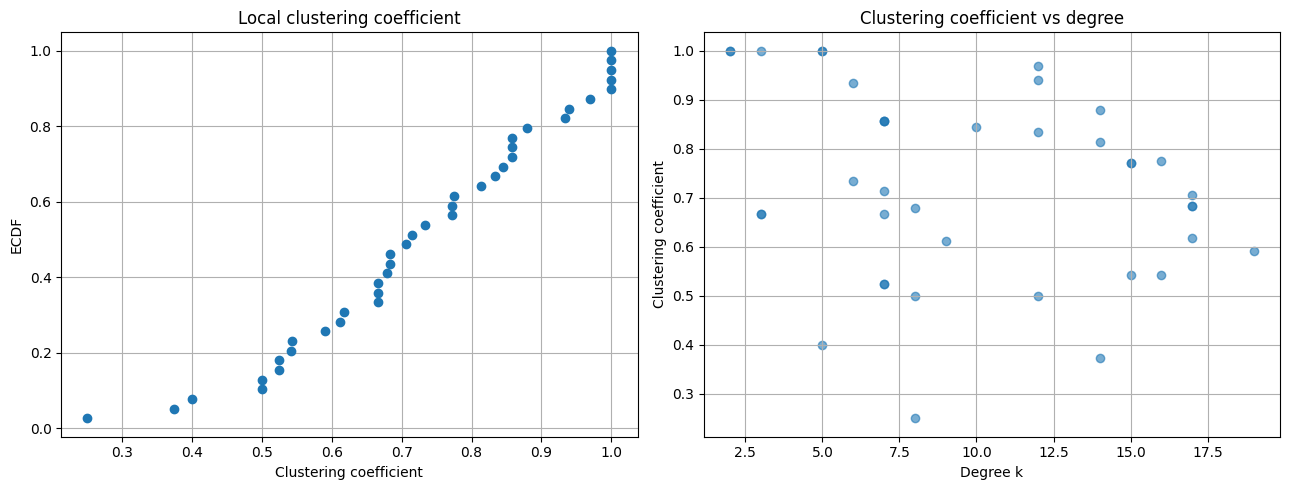

In [20]:
x_cc = np.sort(clustering_values)
y_cc = np.arange(1, len(clustering_values) + 1) / len(clustering_values)

deg_dict = dict(G_cc.degree())
deg_vals = np.array([deg_dict[n] for n in G_cc.nodes()])
cc_vals = np.array([clustering[n] for n in G_cc.nodes()])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_cc, y_cc, marker="o", linestyle="none")
axes[0].set_xlabel("Clustering coefficient")
axes[0].set_ylabel("ECDF")
axes[0].set_title("Local clustering coefficient")
axes[0].grid(True)

axes[1].scatter(deg_vals, cc_vals, alpha=0.6)
axes[1].set_xlabel("Degree k")
axes[1].set_ylabel("Clustering coefficient")
axes[1].set_title("Clustering coefficient vs degree")
axes[1].grid(True)

plt.tight_layout()
plt.show()


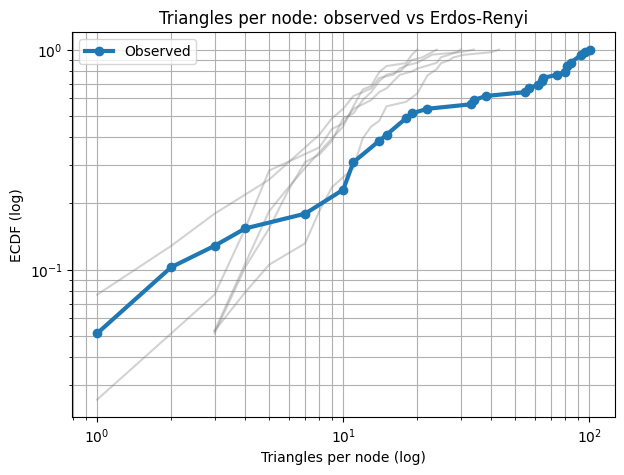

In [21]:
def ecdf_positive(values):
    values = np.asarray(list(values))
    values = np.sort(values[values > 0])
    if len(values) == 0:
        return np.array([]), np.array([])
    x = np.unique(values)
    y = np.searchsorted(values, x, side="right") / len(values)
    return x, y

n_nodes = G_cc.number_of_nodes()
er_prob = nx.density(G_cc)
rng = np.random.default_rng(42)

x_obs, y_obs = ecdf_positive(nx.triangles(G_cc).values())

plt.figure(figsize=(7, 5))
for seed in rng.integers(0, 1_000_000_000, size=5):
    G_er = nx.fast_gnp_random_graph(n_nodes, er_prob, seed=int(seed))
    x_er, y_er = ecdf_positive(nx.triangles(G_er).values())
    if len(x_er):
        plt.loglog(x_er, y_er, alpha=0.35, color="gray")

if len(x_obs):
    plt.loglog(x_obs, y_obs, "-o", linewidth=3, label="Observed")

plt.xlabel("Triangles per node (log)")
plt.ylabel("ECDF (log)")
plt.title("Triangles per node: observed vs Erdos-Renyi")
plt.grid(True, which="both")
plt.legend()
plt.show()


The random graph comparison gives a baseline. Erdos-Renyi graphs with the same number of nodes and similar density do not reproduce the same clustering pattern as the observed EV network. This supports the interpretation that the observed structure is not just a random set of correlations.


## 9. Community Detection

Louvain community detection groups stocks that are more strongly connected to each other than to the rest of the network. In this project, communities can be interpreted as market-implied groups within the EV ecosystem.


In [22]:
partition = community_louvain.best_partition(G_cc, weight="weight", random_state=42)
communities = pd.Series(partition, name="community")

metrics_df = metrics_df.join(communities)

print("Community counts:")
print(communities.value_counts().sort_index())

community_members = (
    metrics_df[["community", "degree", "eigenvector", "betweenness", "pagerank"]]
    .sort_values(["community", "degree"], ascending=[True, False])
)
community_members.head(25)


Community counts:
community
0     3
1     9
2    12
3    15
Name: count, dtype: int64


,community,degree,eigenvector,betweenness,pagerank
006400.KS,0,3,0.001496,0.025605,0.024761
005380.KS,0,3,0.001352,0.025605,0.017898
373220.KS,0,2,0.000294,0.000000,0.019322
IFNNY,1,16,0.204833,0.108282,0.036872
STM,1,15,0.186292,0.081182,0.036120
NXPI,1,12,0.129803,0.075681,0.032223
QCOM,1,7,0.051486,0.001241,0.019516
AMD,1,7,0.035697,0.026679,0.019664
TSM,1,6,0.038969,0.024814,0.018646
INTC,1,6,0.036739,0.000443,0.014891


### What the Communities Represent

Based on the current run, Louvain finds four communities. The community numbers are just labels; the meaning comes from the companies inside each group.

**Community 0: Korean auto/battery cluster**

`005380.KS`, `006400.KS`, and `373220.KS` form a small Korea-linked group. This mainly reflects Hyundai and Korean battery-related firms.

**Community 1: Semiconductor cluster**

`AMD`, `IFNNY`, `INTC`, `NVDA`, `NXPI`, `QCOM`, `STM`, `TSM`, and `TXN` form the semiconductor group. This makes sense because these firms share technology-cycle and chip-supply exposure.

**Community 2: EV/new energy/mobility cluster**

`0175.HK`, `ALB`, `BIDU`, `BYDDY`, `DIDIY`, `LCID`, `LI`, `NIO`, `RIVN`, `SQM`, `TSLA`, and `XPEV` form a group connected to EV manufacturers, Chinese EV names, battery materials, and mobility/autonomy exposure.

**Community 3: Traditional automakers and Tier-1 suppliers**

`6752.T`, `APTV`, `BMW.DE`, `BWA`, `DNZOY`, `F`, `GM`, `HMC`, `LEA`, `MBGYY`, `MGA`, `STLA`, `TM`, `VLEEY`, and `VOW.DE` form the largest community. This group combines traditional automakers with major suppliers, which supports the interpretation that suppliers and manufacturers form the core of the EV ecosystem network.

Overall, the communities show that the EV sector is not one uniform group. The network separates into subgroups based on business role, region, and technology exposure. For portfolio analysis, stocks inside the same community may offer weaker diversification because their market-neutral returns are more closely connected.


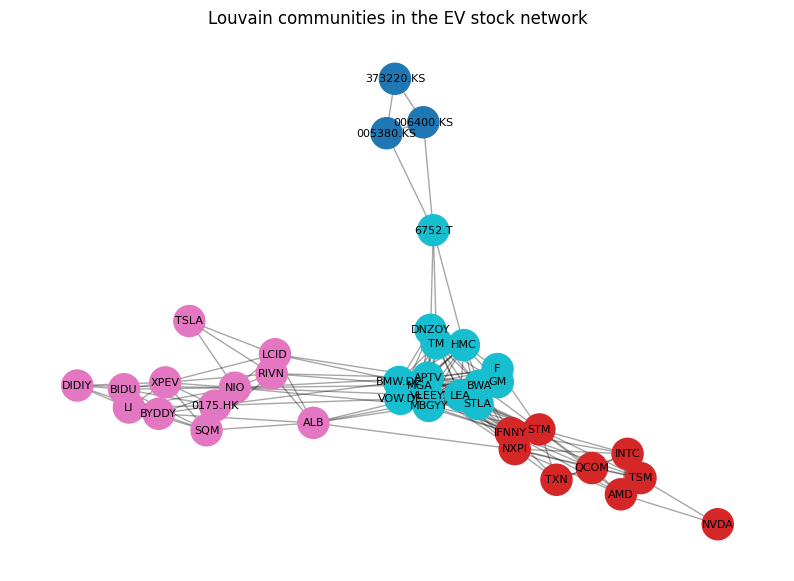

In [23]:
pos_comm = nx.spring_layout(G_cc, seed=42, weight="weight")
node_colors = [partition[n] for n in G_cc.nodes()]

plt.figure(figsize=(10, 7))
nx.draw_networkx_edges(G_cc, pos_comm, alpha=0.35)
nx.draw_networkx_nodes(G_cc, pos_comm, node_size=500, node_color=node_colors, cmap="tab10")
nx.draw_networkx_labels(G_cc, pos_comm, font_size=8)
plt.title("Louvain communities in the EV stock network")
plt.axis("off")
plt.show()


The communities show that stocks are not arranged as one uniform sector. They split into groups that broadly reflect business roles, regions, and technology exposure, such as manufacturers and suppliers, semiconductors, battery/material firms, and EV-focused companies.


## 10. Node2Vec Embeddings

Node2Vec learns a vector representation for each stock by simulating random walks on the graph. Stocks that occupy similar positions in the network should have similar embeddings.

The embeddings are used in two ways:

1. Clustering stocks with KMeans and comparing the result with Louvain communities.
2. Predicting whether a relationship exists between two stocks.


In [24]:
node2vec = Node2Vec(
    G_cc,
    dimensions=32,
    walk_length=20,
    num_walks=200,
    workers=1,
    seed=42,
    weight_key="weight",
    quiet=True,
)

model = node2vec.fit(window=10, min_count=1, batch_words=64)
emb = {str(n): model.wv[str(n)] for n in G_cc.nodes()}

print("Embedding dimension:", len(next(iter(emb.values()))))


Embedding dimension: 32


In [25]:
nodes_list = list(G_cc.nodes())
X_emb = np.vstack([emb[str(n)] for n in nodes_list])

n_communities = len(set(partition.values()))
kmeans = KMeans(n_clusters=n_communities, random_state=42, n_init="auto")
embedding_clusters = kmeans.fit_predict(X_emb)

louvain_labels = np.array([partition[n] for n in nodes_list])
nmi = normalized_mutual_info_score(louvain_labels, embedding_clusters)

print("KMeans clusters:", n_communities)
print("NMI between Louvain and Node2Vec/KMeans:", nmi)

pd.crosstab(
    pd.Series(louvain_labels, name="Louvain"),
    pd.Series(embedding_clusters, name="KMeans"),
)


KMeans clusters: 4
NMI between Louvain and Node2Vec/KMeans: 0.9408625595920103


KMeans,0,1,2,3
Louvain,,,,
0,0,0,3,0
1,0,9,0,0
2,0,0,0,12
3,14,0,1,0


A high NMI score means that the embedding-based clusters are close to the Louvain communities. This suggests that Node2Vec captures meaningful graph structure rather than only producing arbitrary vectors.


## 11. Link Prediction

The link-prediction task tests whether the network structure can help distinguish real stock relationships from true non-edges.

To avoid data leakage, test edges are removed before Node2Vec is trained. Negative examples are sampled from pairs that are non-edges in the original graph, so removed positive test edges are not accidentally labelled as negatives.


In [26]:
def hadamard(u, v, embedding):
    return embedding[str(u)] * embedding[str(v)]


def l1_distance(u, v, embedding):
    return np.abs(embedding[str(u)] - embedding[str(v)])


def fit_node2vec_embeddings(G_train, dimensions=32, walk_length=20, num_walks=200, seed=42):
    n2v = Node2Vec(
        G_train,
        dimensions=dimensions,
        walk_length=walk_length,
        num_walks=num_walks,
        workers=1,
        seed=seed,
        weight_key="weight",
        quiet=True,
    )
    model = n2v.fit(window=10, min_count=1, batch_words=64)
    return {str(n): model.wv[str(n)] for n in G_train.nodes()}


def make_edge_features(edges_pos, edges_neg, embedding, operator="hadamard"):
    operators = {"hadamard": hadamard, "l1": l1_distance}
    op = operators[operator]

    X_pos = np.vstack([op(u, v, embedding) for u, v in edges_pos])
    X_neg = np.vstack([op(u, v, embedding) for u, v in edges_neg])
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(len(edges_pos)), np.zeros(len(edges_neg))])
    return X, y


def best_f1_threshold(y_true, probabilities, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 181)

    best_threshold, best_f1 = 0.5, -1.0
    for threshold_value in grid:
        predictions = (probabilities >= threshold_value).astype(int)
        score = f1_score(y_true, predictions)
        if score > best_f1:
            best_threshold, best_f1 = threshold_value, score

    return float(best_threshold), float(best_f1)


def leakage_free_link_prediction(G, operator="hadamard", test_frac=0.30, seed=42):
    positive_edges = list(G.edges())
    pos_train, pos_test = train_test_split(
        positive_edges,
        test_size=test_frac,
        random_state=seed,
    )

    true_non_edges = list(nx.non_edges(G))
    neg_train, neg_test = train_test_split(
        true_non_edges,
        train_size=len(pos_train),
        test_size=len(pos_test),
        random_state=seed,
    )

    G_train = G.copy()
    G_train.remove_edges_from(pos_test)

    emb_train = fit_node2vec_embeddings(
        G_train,
        dimensions=32,
        walk_length=20,
        num_walks=200,
        seed=seed,
    )

    X_train, y_train = make_edge_features(pos_train, neg_train, emb_train, operator=operator)
    X_test, y_test = make_edge_features(pos_test, neg_test, emb_train, operator=operator)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)),
    ])
    clf.fit(X_train, y_train)

    p_train = clf.predict_proba(X_train)[:, 1]
    p_test = clf.predict_proba(X_test)[:, 1]

    threshold_best, f1_train_best = best_f1_threshold(y_train, p_train)
    yhat_test = (p_test >= threshold_best).astype(int)

    return {
        "operator": operator,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "pos_train": len(pos_train),
        "pos_test": len(pos_test),
        "threshold_train_F1": threshold_best,
        "F1_train_best": f1_train_best,
        "ROC_AUC": roc_auc_score(y_test, p_test),
        "PR_AUC": average_precision_score(y_test, p_test),
        "F1_test": f1_score(y_test, yhat_test),
    }


In [27]:
res_hadamard = leakage_free_link_prediction(G_cc, operator="hadamard", test_frac=0.30, seed=42)
res_l1 = leakage_free_link_prediction(G_cc, operator="l1", test_frac=0.30, seed=42)

pd.DataFrame([res_hadamard, res_l1])[
    ["operator", "pos_train", "pos_test", "threshold_train_F1", "ROC_AUC", "PR_AUC", "F1_test"]
]


,operator,pos_train,pos_test,threshold_train_F1,ROC_AUC,PR_AUC,F1_test
0,hadamard,135,58,0.525,0.916468,0.906399,0.844828
1,l1,135,58,0.375,0.929251,0.936405,0.844037


In [28]:
seeds = list(range(10))

rows = []
for seed in seeds:
    rows.append(leakage_free_link_prediction(G_cc, operator="l1", test_frac=0.30, seed=seed))
    rows.append(leakage_free_link_prediction(G_cc, operator="hadamard", test_frac=0.30, seed=seed))

link_prediction_results = pd.DataFrame(rows)
link_prediction_summary = link_prediction_results.groupby("operator")[["ROC_AUC", "PR_AUC", "F1_test"]].agg(["mean", "std"])

link_prediction_summary


ROC_AUC              PR_AUC             F1_test          
              mean       std      mean       std      mean       std
operator                                                            
hadamard  0.889834  0.046954  0.880982  0.051818  0.823389  0.054319
l1        0.924316  0.047229  0.930567  0.042212  0.836496  0.058927

The multi-seed evaluation checks that the link-prediction result is not driven by one lucky random walk initialization or one particular train-test split. The result should be interpreted as evidence that the network has learnable structure, not as a stock-price forecasting model.


## Key Results from the Capped Run

This table collects the main numerical results from the final run, using data capped at `2026-07-11`.


In [29]:
key_results = pd.DataFrame({
    "item": [
        "cleaned date range",
        "stocks after cleaning",
        "full graph nodes",
        "full graph edges",
        "largest connected component",
        "average clustering",
        "hub threshold",
        "hubs",
        "super-central firms",
        "Node2Vec/Louvain NMI",
        "best mean ROC-AUC",
        "best mean PR-AUC",
        "best mean F1",
    ],
    "value": [
        f"{data_clean.index.min().date()} to {data_clean.index.max().date()}",
        residuals.shape[1],
        G.number_of_nodes(),
        G.number_of_edges(),
        f"{G_cc.number_of_nodes()} nodes, {G_cc.number_of_edges()} edges",
        float(structure_summary.loc[structure_summary["metric"] == "average_clustering", "value"].iloc[0]),
        f">= {hub_threshold:.0f} degree",
        ", ".join(hubs),
        ", ".join(super_central),
        float(nmi),
        float(link_prediction_summary.loc["l1", ("ROC_AUC", "mean")]),
        float(link_prediction_summary.loc["l1", ("PR_AUC", "mean")]),
        float(link_prediction_summary.loc["l1", ("F1_test", "mean")]),
    ],
})

key_results


,item,value
0,cleaned date range,2022-01-27 to 2026-07-10
1,stocks after cleaning,41
2,full graph nodes,41
3,full graph edges,193
4,largest connected component,"39 nodes, 193 edges"
5,average clustering,0.725043
6,hub threshold,>= 16 degree
7,hubs,"MGA, VLEEY, MBGYY, LEA, APTV, BWA, IFNNY"
8,super-central firms,"APTV, MBGYY, MGA, VLEEY"
9,Node2Vec/Louvain NMI,0.940863


## 12. Final Summary

Using data capped at `2026-07-11`, the cleaned sample contains 41 stocks after removing the market benchmark. The largest connected component has 39 nodes and 193 edges, so almost all retained relationships belong to one main EV-sector network.

The network is highly clustered, with an average clustering coefficient of about 0.725. The hub set is formed by firms with degree at least 16, and in this run the hubs are `MGA`, `VLEEY`, `MBGYY`, `LEA`, `APTV`, `BWA`, and `IFNNY`. The firms that appear across all four top-10 centrality lists are `APTV`, `MBGYY`, `MGA`, and `VLEEY`.

The graph machine-learning results support the same interpretation. Node2Vec and KMeans show strong agreement with Louvain communities, with NMI about 0.941. In the multi-seed link-prediction test, the L1 operator performs best on average, with ROC-AUC about 0.924, PR-AUC about 0.931, and F1 about 0.836.

Overall, the project shows that the EV ecosystem has a structured market-implied dependency network. The results are useful for exploratory portfolio and risk analysis because they highlight firms that are highly connected, firms that sit in the network core, and groups of stocks that may not provide strong diversification from each other.

The main limitation is that the network is based on correlations, so it does not prove causality or direct supply-chain dependence. The results also depend on the selected time period, the ticker universe, the benchmark used for market neutralization, and the correlation threshold. For this reason, the project should be viewed as exploratory financial network and risk analysis rather than a trading strategy.
